## 捲積

1.基礎捲積練習

In [1]:
import numpy as np

image = np.array([[1,2,3,4],
          [5,6,7,8],
          [9,10,11,12],
          [13,14,15,16]])

kernel = np.array([[1,1,1],
          [1,1,-1],
          [1,1,1]])

output_image = np.zeros((2,2))

for y in range(output_image.shape[0]):
  for x in range(output_image.shape[1]):
    neighborhood = image[y:y+3, x:x+3]
    calculation = np.sum(neighborhood * kernel)

    output_image[y ,x] = calculation
print(output_image)

[[40. 47.]
 [68. 75.]]


2.把捲積寫成通用式

In [2]:
h, w = image.shape #input img size
kh, kw = kernel.shape #kernal size

output_h = h - kh + 1 #輸出後的高
output_w = w - kw + 1 #輸出後的寬

output = np.zeros((output_h, output_w))

for y in range(output_h):
  for x in range(output_w):
    neighborhood = image[y:y+kh, x:x+kw]
    output[y, x] = np.sum(neighborhood * kernel)

print(output)

[[40. 47.]
 [68. 75.]]


3.加入padding

In [3]:
padded_image = np.pad(image, pad_width=1, mode='constant', constant_values=0)

h, w = padded_image.shape #input img size
kh, kw = kernel.shape #kernal size

output_h = h - kh + 1 #輸出後的高
output_w = w - kw + 1 #輸出後的寬

output = np.zeros((output_h, output_w))

for y in range(output_h):
  for x in range(output_w):
    neighborhood = padded_image[y:y+kh, x:x+kw]
    output[y, x] = np.sum(neighborhood * kernel)

print(output)

[[10. 18. 22. 22.]
 [21. 40. 47. 45.]
 [37. 68. 75. 69.]
 [18. 42. 46. 54.]]


4.加入stride

In [4]:
stride = 2 #設定步長=2

padded_image = np.pad(image, pad_width=1, mode='constant', constant_values=0)
h, w = padded_image.shape #input img size
kh, kw = kernel.shape #kernal size

output_h = (h - kh)//stride + 1 #輸出後的高
output_w = (w - kw)//stride + 1 #輸出後的寬

output = np.zeros((output_h, output_w))

for y in range(output_h):
  for x in range(output_w):
    y_start = y*stride
    x_start = x*stride
    neighborhood = padded_image[y_start:y_start+kh, x_start:x_start+kw]
    output[y, x] = np.sum(neighborhood * kernel)

print(output)

[[10. 22.]
 [37. 75.]]


output_image_size = (W - K + 2P) / S + 1

## 本日練習:將7x7矩陣使用5x5捲積核捲積，輸出特徵矩陣要和原圖矩陣大小相同

In [6]:
hw_image = np.array([
    [1,2,3,4,5,6,7],
    [2,4,5,5,6,7,7],
    [1,3,4,5,2,3,4],
    [5,6,3,2,4,5,6],
    [1,2,3,4,6,7,8],
    [2,7,6,8,3,4,5],
    [7,8,2,6,3,4,6]
])

kernel = np.array([
    [1,0,0,0,0],
    [0,1,0,0,0],
    [0,0,1,0,0],
    [0,0,0,1,0],
    [0,0,0,0,1]
])

## 如果還有時間，看看不同的kernel吧

In [7]:
import cv2
img_lenna = cv2.imread('Lenna.png', cv2.IMREAD_GRAYSCALE)
print(img_lenna.shape)

(512, 512)


In [8]:
print(img_lenna)

[[169 169 168 ... 175 162 138]
 [169 169 168 ... 175 162 138]
 [169 169 168 ... 175 162 138]
 ...
 [ 53  53  59 ... 115 112 114]
 [ 53  53  64 ... 117 118 122]
 [ 53  53  64 ... 117 118 122]]


In [9]:
padded_hw_image = np.pad(img_lenna, pad_width=1,mode='constant', constant_values=0)


kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

h, w = padded_hw_image.shape
kh, kw = kernel.shape
output = np.zeros((img_lenna.shape[0], img_lenna.shape[1]))

output_h = h - kh + 1
output_w = w - kw + 1

for y in range(output_h):
  for x in range(output_w):
    neighborhood = padded_hw_image[y:y+kh, x:x+kw]
    output[y, x] = np.sum(neighborhood * kernel)
print(output)

[[845. 509. 504. ... 545. 508. 642.]
 [507.   3.   0. ...  30.  33. 342.]
 [507.   3.   0. ...  30.  33. 342.]
 ...
 [153. -29.   8. ...   9. -22. 342.]
 [159. -28.  49. ...  12.   7. 392.]
 [265. 137. 220. ... 353. 348. 618.]]


In [10]:
output_norm = output - output.min()
output_norm = output_norm / output_norm.max() * 255
output_norm = output_norm.astype(np.uint8)

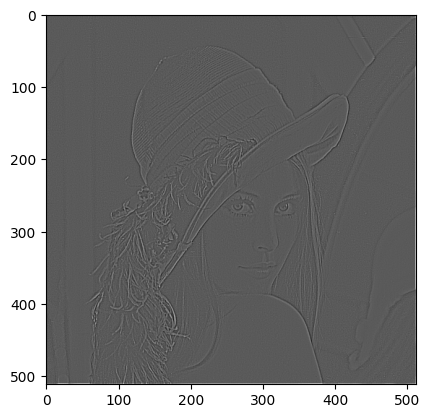

In [11]:
import matplotlib.pyplot as plt
plt.imshow(output_norm, cmap='gray')